In [26]:
# ================================
# 1. DATA UNDERSTANDING
# ================================
import pandas as pd

# Load data
train = pd.read_csv("train.csv")

print("5 Data Teratas:")
print(train.head())

print("\nInfo Dataset:")
print(train.info())

print("\nStatistik Deskriptif:")
print(train.describe())

print("\nNama Kolom:")
print(train.columns)

5 Data Teratas:
              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----

In [27]:
# ================================
# 2. DATA PREPROCESSING
# ================================
import numpy as np

# Copy data biar aman
df = train.copy()

# 🔥 HAPUS DATA LEAKAGE
df = df.drop(columns=['casual', 'registered'])

# ----- HANDLE MISSING VALUE -----
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing value setelah cleaning:")
print(df.isnull().sum())


# ================================
# 🔥 TAMBAHAN: HANDLE OUTLIER (IQR)
# ================================
for col in df.select_dtypes(include=np.number).columns:
    if col != 'count':  # jangan ubah target
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # CAPPING
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Total data setelah preprocessing:", len(df))


Missing value setelah cleaning:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
count         0
dtype: int64
Total data setelah preprocessing: 10886


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13216\2418338548.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13216\2418338548.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [28]:
# ================================
# FEATURE ENGINEERING
# ================================

# Ubah datetime
df['datetime'] = pd.to_datetime(df['datetime'])

# Ekstrak fitur waktu
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['dayofweek'] = df['datetime'].dt.dayofweek

# 🔥 fitur tambahan penting
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
df['temp_diff'] = df['temp'] - df['atemp']

# Drop datetime
df = df.drop(columns=['datetime'])

print("\nFitur setelah FE:")
print(df.columns)


Fitur setelah FE:
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'count', 'hour', 'day', 'month', 'dayofweek',
       'is_weekend', 'temp_diff'],
      dtype='object')


In [29]:
train = pd.read_csv("train.csv")

# Hapus kolom leakage
for col in ['casual', 'registered']:
    if col in train.columns:
        train = train.drop(columns=[col])

train.to_csv("train_bersih.csv", index=False)
train = pd.read_csv("train_bersih.csv")

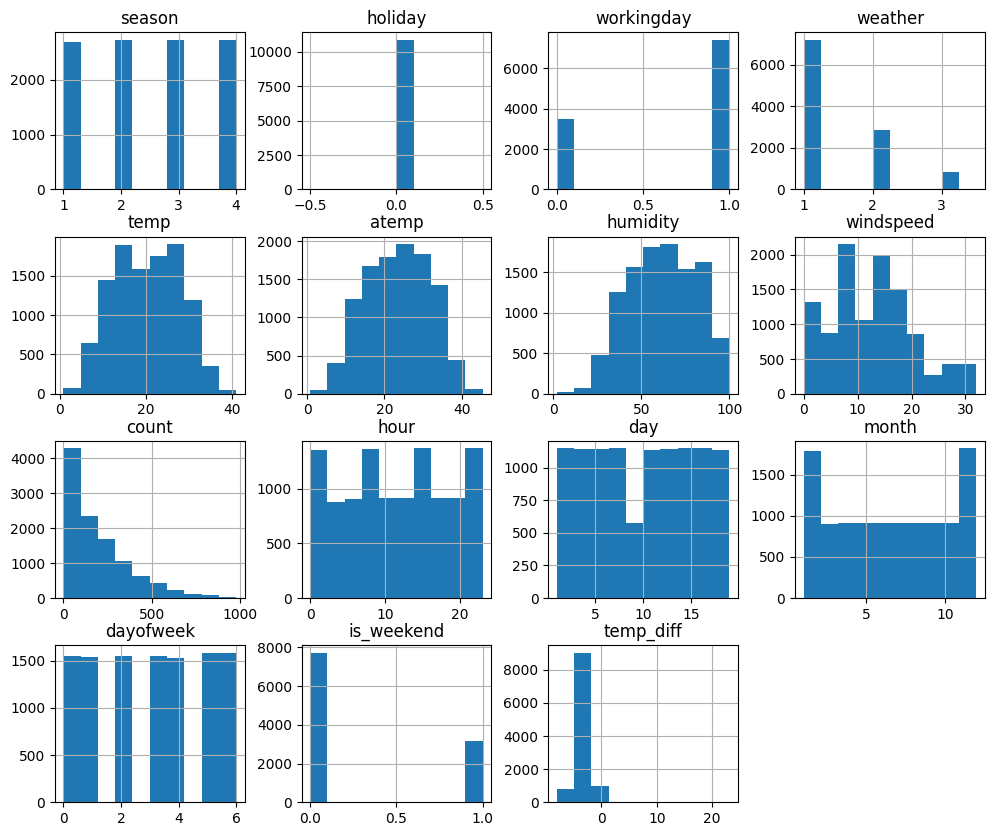

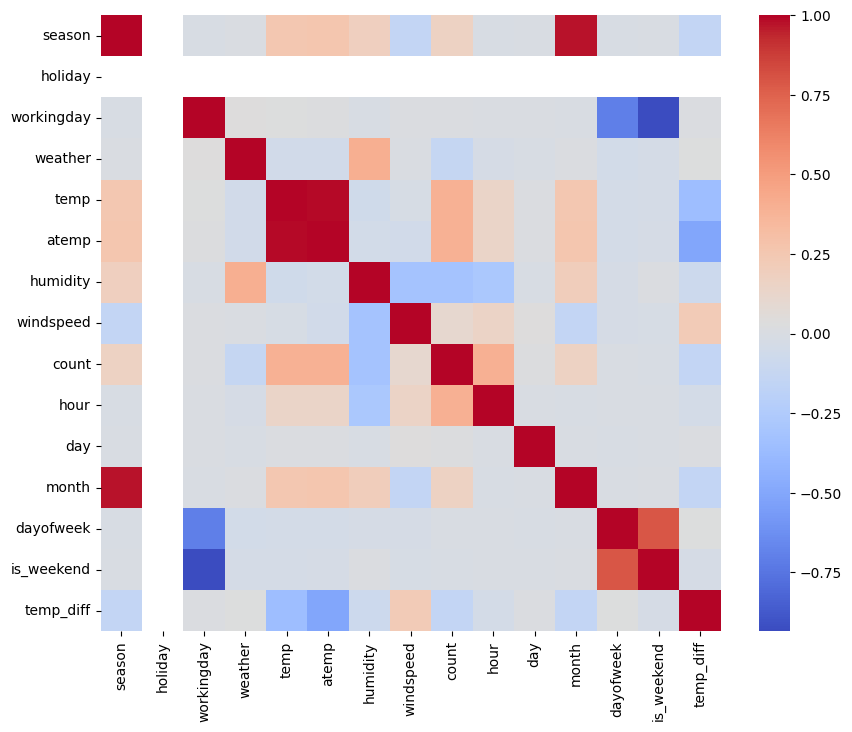

In [30]:
# ================================
# 4. EDA
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# Distribusi
df.hist(figsize=(12,10))
plt.show()

# Korelasi
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [31]:
# ================================
# 5. DATA SPLITTING
# ================================
from sklearn.model_selection import train_test_split

target = 'count'

X = df.drop(columns=[target])
y = df[target]

splits = [
    (0.7, 0.3),
    (0.8, 0.2),
    (0.9, 0.1)
]

In [32]:
# ================================
# 6. MODEL BUILDING
# ================================
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [33]:

# ================================
# 7. TRAINING + TUNING
# ================================
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score

results = []

for train_size, test_size in splits:
    print(f"\n===== Split {train_size}:{test_size} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # ========================
    # RANDOM FOREST
    # ========================
    rf = RandomForestRegressor()

    rf_params = {
        'n_estimators': [200, 300],
        'max_depth': [10, 15]
    }

    rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='r2')
    rf_grid.fit(X_train, y_train)

    rf_pred = rf_grid.predict(X_test)
    rf_r2 = r2_score(y_test, rf_pred)

    print("Random Forest:", rf_r2)


    # ========================
    # XGBOOST
    # ========================
    xgb = XGBRegressor()

    xgb_params = {
        'n_estimators': [300, 500],
        'max_depth': [6, 8],
        'learning_rate': [0.05],
        'subsample': [0.8],
        'colsample_bytree': [0.8]
    }

    xgb_random = RandomizedSearchCV(xgb, xgb_params, n_iter=4, cv=3, scoring='r2')
    xgb_random.fit(X_train, y_train)

    xgb_pred = xgb_random.predict(X_test)
    xgb_r2 = r2_score(y_test, xgb_pred)

    print("XGBoost:", xgb_r2)


    # ========================
    # LIGHTGBM
    # ========================
    lgbm = LGBMRegressor()

    lgbm_params = {
        'n_estimators': [300, 500],
        'num_leaves': [31, 50],
        'learning_rate': [0.05],
        'subsample': [0.8]
    }

    lgbm_grid = GridSearchCV(lgbm, lgbm_params, cv=3, scoring='r2')
    lgbm_grid.fit(X_train, y_train)

    lgbm_pred = lgbm_grid.predict(X_test)
    lgbm_r2 = r2_score(y_test, lgbm_pred)

    print("LightGBM:", lgbm_r2)

    # Simpan hasil
    results.append({
        "Split": f"{int(train_size*100)}:{int(test_size*100)}",
        "RandomForest": rf_r2,
        "XGBoost": xgb_r2,
        "LightGBM": lgbm_r2
    })


===== Split 0.7:0.3 =====
Random Forest: 0.8622081517740531
XGBoost: 0.911173939704895
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000897 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 471
[LightGBM] [Info] Number of data points in the train set: 5080, number of used features: 13
[LightGBM] [Info] Start training from score 194.899016
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 470
[LightGBM] [Info] Number of data points in the train set: 5080, number of used features: 13
[LightGBM] [Info] Start training from score 188.528937
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001047 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 471
[LightGBM] [Info] Number of data 

In [34]:
# ================================
# 8. EVALUASI MODEL LENGKAP
# ================================
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

eval_results = []

for train_size, test_size in splits:
    print(f"\n===== Split {train_size}:{test_size} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # ========================
    # RANDOM FOREST
    # ========================
    rf = RandomForestRegressor()
    rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='r2')
    rf_grid.fit(X_train, y_train)

    rf_pred = rf_grid.predict(X_test)

    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_mse = mean_squared_error(y_test, rf_pred)
    rf_rmse = np.sqrt(rf_mse)
    rf_r2 = r2_score(y_test, rf_pred)

    # ========================
    # XGBOOST
    # ========================
    xgb = XGBRegressor()
    xgb_random = RandomizedSearchCV(xgb, xgb_params, n_iter=4, cv=3, scoring='r2')
    xgb_random.fit(X_train, y_train)

    xgb_pred = xgb_random.predict(X_test)

    xgb_mae = mean_absolute_error(y_test, xgb_pred)
    xgb_mse = mean_squared_error(y_test, xgb_pred)
    xgb_rmse = np.sqrt(xgb_mse)
    xgb_r2 = r2_score(y_test, xgb_pred)

    # ========================
    # LIGHTGBM
    # ========================
    lgbm = LGBMRegressor()
    lgbm_grid = GridSearchCV(lgbm, lgbm_params, cv=3, scoring='r2')
    lgbm_grid.fit(X_train, y_train)

    lgbm_pred = lgbm_grid.predict(X_test)

    lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
    lgbm_mse = mean_squared_error(y_test, lgbm_pred)
    lgbm_rmse = np.sqrt(lgbm_mse)
    lgbm_r2 = r2_score(y_test, lgbm_pred)

    # ========================
    # SIMPAN HASIL
    # ========================
    eval_results.append({
        "Split": f"{int(train_size*100)}:{int(test_size*100)}",

        # Random Forest
        "RF_MAE": rf_mae,
        "RF_MSE": rf_mse,
        "RF_RMSE": rf_rmse,
        "RF_R2": rf_r2,

        # XGBoost
        "XGB_MAE": xgb_mae,
        "XGB_MSE": xgb_mse,
        "XGB_RMSE": xgb_rmse,
        "XGB_R2": xgb_r2,

        # LightGBM
        "LGBM_MAE": lgbm_mae,
        "LGBM_MSE": lgbm_mse,
        "LGBM_RMSE": lgbm_rmse,
        "LGBM_R2": lgbm_r2
    })

# ================================
# 9. TAMPILKAN HASIL
# ================================
df_eval = pd.DataFrame(eval_results)

print("\n=== HASIL EVALUASI MODEL ===")
print(df_eval)


===== Split 0.7:0.3 =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 471
[LightGBM] [Info] Number of data points in the train set: 5080, number of used features: 13
[LightGBM] [Info] Start training from score 194.899016
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000441 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 470
[LightGBM] [Info] Number of data points in the train set: 5080, number of used features: 13
[LightGBM] [Info] Start training from score 188.528937
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000466 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 471
[LightGBM] [Info] Number of data points in the train set: 5080, number of used features: 13
[L

In [35]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

eval_results = []

for train_size, test_size in splits:
    print(f"\n===== Split {train_size}:{test_size} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # ========================
    # RANDOM FOREST
    # ========================
    rf = RandomForestRegressor()
    rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='r2', return_train_score=True)
    rf_grid.fit(X_train, y_train)

    rf_best = rf_grid.best_estimator_

    rf_train_pred = rf_best.predict(X_train)
    rf_test_pred  = rf_best.predict(X_test)

    rf_r2_train = r2_score(y_train, rf_train_pred)
    rf_r2_test  = r2_score(y_test, rf_test_pred)
    rf_r2_val   = rf_grid.best_score_   # dari cross-validation

    # ========================
    # XGBOOST
    # ========================
    xgb = XGBRegressor()
    xgb_random = RandomizedSearchCV(
        xgb, xgb_params, n_iter=4, cv=3,
        scoring='r2', return_train_score=True
    )
    xgb_random.fit(X_train, y_train)

    xgb_best = xgb_random.best_estimator_

    xgb_train_pred = xgb_best.predict(X_train)
    xgb_test_pred  = xgb_best.predict(X_test)

    xgb_r2_train = r2_score(y_train, xgb_train_pred)
    xgb_r2_test  = r2_score(y_test, xgb_test_pred)
    xgb_r2_val   = xgb_random.best_score_

    # ========================
    # LIGHTGBM
    # ========================
    lgbm = LGBMRegressor()
    lgbm_grid = GridSearchCV(
        lgbm, lgbm_params, cv=3,
        scoring='r2', return_train_score=True
    )
    lgbm_grid.fit(X_train, y_train)

    lgbm_best = lgbm_grid.best_estimator_

    lgbm_train_pred = lgbm_best.predict(X_train)
    lgbm_test_pred  = lgbm_best.predict(X_test)

    lgbm_r2_train = r2_score(y_train, lgbm_train_pred)
    lgbm_r2_test  = r2_score(y_test, lgbm_test_pred)
    lgbm_r2_val   = lgbm_grid.best_score_

    # ========================
    # SIMPAN
    # ========================
    eval_results.append({
        "Split": f"{int(train_size*100)}:{int(test_size*100)}",

        # RF
        "RF_Train": rf_r2_train,
        "RF_Val": rf_r2_val,
        "RF_Test": rf_r2_test,

        # XGB
        "XGB_Train": xgb_r2_train,
        "XGB_Val": xgb_r2_val,
        "XGB_Test": xgb_r2_test,

        # LGBM
        "LGBM_Train": lgbm_r2_train,
        "LGBM_Val": lgbm_r2_val,
        "LGBM_Test": lgbm_r2_test
    })

# ========================
# HASIL
# ========================
df_eval = pd.DataFrame(eval_results)

print("\n=== CEK OVERFITTING ===")
print(df_eval)


===== Split 0.7:0.3 =====
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 471
[LightGBM] [Info] Number of data points in the train set: 5080, number of used features: 13
[LightGBM] [Info] Start training from score 194.899016
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000574 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 470
[LightGBM] [Info] Number of data points in the train set: 5080, number of used features: 13
[LightGBM] [Info] Start training from score 188.528937
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000612 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 471
[LightGBM] [Info] Number of da

In [36]:
# ================================
# 1. LOAD DATA FINAL
# ================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMRegressor

# Load data train bersih
train = pd.read_csv("train_bersih.csv")

# Load data test
test = pd.read_csv("test.csv")

print("Train Columns:", train.columns)
print("Test Columns:", test.columns)

Train Columns: Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'count'],
      dtype='object')
Test Columns: Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed'],
      dtype='object')


In [37]:
# ================================
# 2. PREPROCESS TEST DATA
# ================================
import pandas as pd
import numpy as np

# Reload test data to ensure a clean state for preprocessing
test = pd.read_csv("test.csv")

# Hapus kolom leakage jika ada
columns_to_drop = ['casual', 'registered']
for col in columns_to_drop:
    if col in test.columns:
        test = test.drop(columns=[col])

# Isi missing value numerik dengan mean
for col in test.select_dtypes(include=np.number).columns:
    test[col].fillna(test[col].mean(), inplace=True)

for col in test.select_dtypes(include='object').columns:
    test[col].fillna(test[col].mode()[0], inplace=True)

# Feature engineering datetime
test['datetime'] = pd.to_datetime(test['datetime'])
test['hour'] = test['datetime'].dt.hour
test['day'] = test['datetime'].dt.day
test['month'] = test['datetime'].dt.month
test['dayofweek'] = test['datetime'].dt.dayofweek

# 🔥 fitur tambahan penting (sesuai dengan train)
test['is_weekend'] = test['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
test['temp_diff'] = test['temp'] - test['atemp']

# Hapus kolom datetime asli
test = test.drop(columns=['datetime'])

# Encode kolom kategorikal (This step is currently not needed as there are no object columns left, but kept for consistency if future changes introduce them)
# le = LabelEncoder()
# for col in test.select_dtypes(include='object').columns:
#     test[col] = le.fit_transform(test[col])

print("\nTest data setelah preprocessing:")
print(test.head())


Test data setelah preprocessing:
   season  holiday  workingday  weather   temp   atemp  humidity  windspeed  \
0       1        0           1        1  10.66  11.365        56    26.0027   
1       1        0           1        1  10.66  13.635        56     0.0000   
2       1        0           1        1  10.66  13.635        56     0.0000   
3       1        0           1        1  10.66  12.880        56    11.0014   
4       1        0           1        1  10.66  12.880        56    11.0014   

   hour  day  month  dayofweek  is_weekend  temp_diff  
0     0   20      1          3           0     -0.705  
1     1   20      1          3           0     -2.975  
2     2   20      1          3           0     -2.975  
3     3   20      1          3           0     -2.220  
4     4   20      1          3           0     -2.220  


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13216\1697994958.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test[col].fillna(test[col].mean(), inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13216\1697994958.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [38]:
# ================================
# 3. TRAINING LIGHTGBM FINAL
# ================================

# Feature engineering datetime for the final train data
train['datetime'] = pd.to_datetime(train['datetime'])
train['hour'] = train['datetime'].dt.hour
train['day'] = train['datetime'].dt.day
train['month'] = train['datetime'].dt.month
train['dayofweek'] = train['datetime'].dt.dayofweek

# 🔥 fitur tambahan penting (same as df)
train['is_weekend'] = train['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
train['temp_diff'] = train['temp'] - train['atemp']

# Hapus kolom datetime asli
train = train.drop(columns=['datetime'])

X_train = train.drop(columns=['count'])
y_train = np.log1p(train['count'])  # log transform untuk stabilisasi

# Model LightGBM dengan parameter terbaik hasil tuning sebelumnya
lgbm_final = LGBMRegressor(
    n_estimators=500,
    num_leaves=70,
    learning_rate=0.05,
    subsample=0.8
)

lgbm_final.fit(X_train, y_train)
print("\nModel LightGBM final berhasil dilatih.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 519
[LightGBM] [Info] Number of data points in the train set: 10886, number of used features: 14
[LightGBM] [Info] Start training from score 4.591364

Model LightGBM final berhasil dilatih.


In [39]:
# ================================
# 4. PREDIKSI TEST DATA
# ================================
pred_test = lgbm_final.predict(test)
pred_test = np.expm1(pred_test)  # balik dari log transform

# 🔥 TAMBAHAN PENTING
pred_test = np.clip(pred_test, 0, 1000)  # biar tidak aneh
pred_test = np.round(pred_test).astype(int)  # ✅ BULATKAN

# Buat DataFrame
submission = pd.DataFrame({
    "id": test.index,  # atau pakai kolom ID asli kalau ada
    "count": pred_test
})

print("\nPrediksi 5 data pertama:")
print(submission.head())

# Simpan ke CSV
submission.to_csv("prediksi_test_lightgbm.csv", index=False)
print("\n✅ Prediksi test.csv berhasil disimpan sebagai prediksi_test_lightgbm.csv")


Prediksi 5 data pertama:
   id  count
0   0     13
1   1      5
2   2      5
3   3      3
4   4      2

✅ Prediksi test.csv berhasil disimpan sebagai prediksi_test_lightgbm.csv
